In [282]:
import os
import sys
lib_path = os.path.abspath(os.path.join(os.path.abspath(''), 'functions/'))
sys.path.append(lib_path)
# need to append our functions dir to the path! 

import SD_raster_loading
import SD_NC_loading
import netCDF4
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import dalecLoad
import spectralConv
import seaborn as sns
import scipy as sp
from datetime import timedelta
import matplotlib.dates as mdates

from sklearn.metrics import r2_score, mean_squared_error

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Lasso, Ridge, ElasticNet, LinearRegression
from sklearn.model_selection import GridSearchCV

In [387]:
def MAE(true, pred):
    return np.sum(np.abs(true - pred))/len(pred)
def MAPE(true, pred):
    return 100 * np.sum(np.abs((true - pred)/true))/len(pred)
def RMSE(true, pred):
    return np.sqrt(np.sum((true - pred)**2)/len(pred))

def RMSD(y_true, y_est):
    '''
    logspace RMSE
    '''
    y_true = np.log10(y_true)
    y_est = np.log10(y_est)
    return 10**(np.sqrt(np.mean((y_true - y_est)**2)))-1

def MAD(y_true: np.ndarray, y_est: np.ndarray) -> float:
    ''' Return the mean absolute difference (MAD) '''
    y_true = np.log10(y_true)
    y_est = np.log10(y_est)
    return 10**np.mean(np.abs(y_true - y_est))-1

def MAPD(y_true: np.ndarray, y_est: np.ndarray) -> float:
    ''' Return the median absolute percentage difference (MAPD) '''
    return np.nanmedian(np.abs((y_true - y_est) / y_true)) * 100


def MDSA(y_true: np.ndarray, y_est: np.ndarray) -> float:
    ''' Return the median symmetric accuracy (MdSA) '''
    return (np.exp(np.nanmedian(np.abs(np.log(y_est / y_true)))) - 1) * 100


def SSPB(y_true: np.ndarray, y_est: np.ndarray) -> float:
    ''' Return the symmetric signed percentage bias (SSPB) '''
    med = np.nanmedian( np.log(y_est / y_true) )
    return np.sign(med) * (np.exp(np.abs(med)) - 1) * 100

def MRD(true, pred):
    '''mean relative difference'''
    return np.sum(((pred - true)/true)) / len(pred)

In [284]:
def p_sig(p_val):
    if p_val >= 0.05:
        return '(ns)'
    elif p_val >= 0.01:
        return '*'
    elif p_val >= 0.001:
        return '**'
    else:
        return '***'

In [285]:
coord = [56.147005, -3.923311] # this is approx the location of the DALEC + ~10 m out which looks less edge effected 
#coord = [56.14693897799395, -3.923458784671348] # this is approx the location of the DALEC
#coord = [56.146746528609306, -3.92285731543299] # this is perhaps a deeper part of the loch
S2_acolite = SD_NC_loading.load_multiple_SDs('S2_downloads/acolite_output/',
                                        coord, skipSameDay=False,
                                        pixel_grid_shape=(3,3),
                                        filetype="L2W.nc",
                                        variable='Rrs',
                                        div_by_pi=False,)

date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 f

In [286]:
coord = [56.147005, -3.923311] # this is approx the location of the DALEC + ~10 m out which looks less edge effected 
#coord = [56.14693897799395, -3.923458784671348] # this is approx the location of the DALEC
#coord = [56.146746528609306, -3.92285731543299] # this is perhaps a deeper part of the loch
S2_c2rcc = SD_NC_loading.load_multiple_SDs('C2RCC/full_S2_c2rcc/',
                                            coord, skipSameDay=False,
                                            pixel_grid_shape=(3,3),
                                            filetype=".nc",
                                            variable='rrs',
                                            date_name='start_date',
                                            wavelengths_S2A=[443., 492., 560., 665., 704., 740., 783., 865.],
                                            wavelengths_S2B=[442., 492., 559., 665., 704., 739., 780., 864.],
                                            div_by_pi=False,)

are you sure you know the wavelength order? - best double check it!
rrs_B1 : 443.0
rrs_B2 : 492.0
rrs_B3 : 560.0
rrs_B4 : 665.0
rrs_B5 : 704.0
rrs_B6 : 740.0
rrs_B7 : 783.0
rrs_B8A : 865.0
are you sure you know the wavelength order? - best double check it!
rrs_B1 : 442.0
rrs_B2 : 492.0
rrs_B3 : 559.0
rrs_B4 : 665.0
rrs_B5 : 704.0
rrs_B6 : 739.0
rrs_B7 : 780.0
rrs_B8A : 864.0
are you sure you know the wavelength order? - best double check it!
rrs_B1 : 442.0
rrs_B2 : 492.0
rrs_B3 : 559.0
rrs_B4 : 665.0
rrs_B5 : 704.0
rrs_B6 : 739.0
rrs_B7 : 780.0
rrs_B8A : 864.0
are you sure you know the wavelength order? - best double check it!
rrs_B1 : 442.0
rrs_B2 : 492.0
rrs_B3 : 559.0
rrs_B4 : 665.0
rrs_B5 : 704.0
rrs_B6 : 739.0
rrs_B7 : 780.0
rrs_B8A : 864.0
are you sure you know the wavelength order? - best double check it!
rrs_B1 : 443.0
rrs_B2 : 492.0
rrs_B3 : 560.0
rrs_B4 : 665.0
rrs_B5 : 704.0
rrs_B6 : 740.0
rrs_B7 : 783.0
rrs_B8A : 865.0
are you sure you know the wavelength order? - best doub

are you sure you know the wavelength order? - best double check it!
rrs_B1 : 442.0
rrs_B2 : 492.0
rrs_B3 : 559.0
rrs_B4 : 665.0
rrs_B5 : 704.0
rrs_B6 : 739.0
rrs_B7 : 780.0
rrs_B8A : 864.0
are you sure you know the wavelength order? - best double check it!
rrs_B1 : 442.0
rrs_B2 : 492.0
rrs_B3 : 559.0
rrs_B4 : 665.0
rrs_B5 : 704.0
rrs_B6 : 739.0
rrs_B7 : 780.0
rrs_B8A : 864.0
are you sure you know the wavelength order? - best double check it!
rrs_B1 : 443.0
rrs_B2 : 492.0
rrs_B3 : 560.0
rrs_B4 : 665.0
rrs_B5 : 704.0
rrs_B6 : 740.0
rrs_B7 : 783.0
rrs_B8A : 865.0
are you sure you know the wavelength order? - best double check it!
rrs_B1 : 443.0
rrs_B2 : 492.0
rrs_B3 : 560.0
rrs_B4 : 665.0
rrs_B5 : 704.0
rrs_B6 : 740.0
rrs_B7 : 783.0
rrs_B8A : 865.0
are you sure you know the wavelength order? - best double check it!
rrs_B1 : 443.0
rrs_B2 : 492.0
rrs_B3 : 560.0
rrs_B4 : 665.0
rrs_B5 : 704.0
rrs_B6 : 740.0
rrs_B7 : 783.0
rrs_B8A : 865.0
are you sure you know the wavelength order? - best doub

are you sure you know the wavelength order? - best double check it!
rrs_B1 : 443.0
rrs_B2 : 492.0
rrs_B3 : 560.0
rrs_B4 : 665.0
rrs_B5 : 704.0
rrs_B6 : 740.0
rrs_B7 : 783.0
rrs_B8A : 865.0
are you sure you know the wavelength order? - best double check it!
rrs_B1 : 443.0
rrs_B2 : 492.0
rrs_B3 : 560.0
rrs_B4 : 665.0
rrs_B5 : 704.0
rrs_B6 : 740.0
rrs_B7 : 783.0
rrs_B8A : 865.0
are you sure you know the wavelength order? - best double check it!
rrs_B1 : 442.0
rrs_B2 : 492.0
rrs_B3 : 559.0
rrs_B4 : 665.0
rrs_B5 : 704.0
rrs_B6 : 739.0
rrs_B7 : 780.0
rrs_B8A : 864.0
are you sure you know the wavelength order? - best double check it!
rrs_B1 : 443.0
rrs_B2 : 492.0
rrs_B3 : 560.0
rrs_B4 : 665.0
rrs_B5 : 704.0
rrs_B6 : 740.0
rrs_B7 : 783.0
rrs_B8A : 865.0
are you sure you know the wavelength order? - best double check it!
rrs_B1 : 442.0
rrs_B2 : 492.0
rrs_B3 : 559.0
rrs_B4 : 665.0
rrs_B5 : 704.0
rrs_B6 : 739.0
rrs_B7 : 780.0
rrs_B8A : 864.0
are you sure you know the wavelength order? - best doub

In [287]:
coord = [56.147005, -3.923311] # this is approx the location of the DALEC + ~10 m out which looks less edge effected 
#coord = [56.14693897799395, -3.923458784671348] # this is approx the location of the DALEC
#coord = [56.146746528609306, -3.92285731543299] # this is perhaps a deeper part of the loch
S2_c2rcX = SD_NC_loading.load_multiple_SDs('C2RCC/full_s2_c2rcc_c2X_all_valid_salin03/',
                                            coord, skipSameDay=False,
                                            pixel_grid_shape=(3,3),
                                            filetype=".nc",
                                            variable='rrs',
                                            date_name='start_date',
                                            wavelengths_S2A=[443., 492., 560., 665., 704., 740., 783., 865.],
                                            wavelengths_S2B=[442., 492., 559., 665., 704., 739., 780., 864.],
                                            div_by_pi=False,)

are you sure you know the wavelength order? - best double check it!
rrs_B1 : 442.0
rrs_B2 : 492.0
rrs_B3 : 559.0
rrs_B4 : 665.0
rrs_B5 : 704.0
rrs_B6 : 739.0
rrs_B7 : 780.0
rrs_B8A : 864.0
are you sure you know the wavelength order? - best double check it!
rrs_B1 : 442.0
rrs_B2 : 492.0
rrs_B3 : 559.0
rrs_B4 : 665.0
rrs_B5 : 704.0
rrs_B6 : 739.0
rrs_B7 : 780.0
rrs_B8A : 864.0
are you sure you know the wavelength order? - best double check it!
rrs_B1 : 443.0
rrs_B2 : 492.0
rrs_B3 : 560.0
rrs_B4 : 665.0
rrs_B5 : 704.0
rrs_B6 : 740.0
rrs_B7 : 783.0
rrs_B8A : 865.0
are you sure you know the wavelength order? - best double check it!
rrs_B1 : 442.0
rrs_B2 : 492.0
rrs_B3 : 559.0
rrs_B4 : 665.0
rrs_B5 : 704.0
rrs_B6 : 739.0
rrs_B7 : 780.0
rrs_B8A : 864.0
are you sure you know the wavelength order? - best double check it!
rrs_B1 : 442.0
rrs_B2 : 492.0
rrs_B3 : 559.0
rrs_B4 : 665.0
rrs_B5 : 704.0
rrs_B6 : 739.0
rrs_B7 : 780.0
rrs_B8A : 864.0
are you sure you know the wavelength order? - best doub

are you sure you know the wavelength order? - best double check it!
rrs_B1 : 443.0
rrs_B2 : 492.0
rrs_B3 : 560.0
rrs_B4 : 665.0
rrs_B5 : 704.0
rrs_B6 : 740.0
rrs_B7 : 783.0
rrs_B8A : 865.0
are you sure you know the wavelength order? - best double check it!
rrs_B1 : 443.0
rrs_B2 : 492.0
rrs_B3 : 560.0
rrs_B4 : 665.0
rrs_B5 : 704.0
rrs_B6 : 740.0
rrs_B7 : 783.0
rrs_B8A : 865.0
are you sure you know the wavelength order? - best double check it!
rrs_B1 : 442.0
rrs_B2 : 492.0
rrs_B3 : 559.0
rrs_B4 : 665.0
rrs_B5 : 704.0
rrs_B6 : 739.0
rrs_B7 : 780.0
rrs_B8A : 864.0
are you sure you know the wavelength order? - best double check it!
rrs_B1 : 443.0
rrs_B2 : 492.0
rrs_B3 : 560.0
rrs_B4 : 665.0
rrs_B5 : 704.0
rrs_B6 : 740.0
rrs_B7 : 783.0
rrs_B8A : 865.0
are you sure you know the wavelength order? - best double check it!
rrs_B1 : 442.0
rrs_B2 : 492.0
rrs_B3 : 559.0
rrs_B4 : 665.0
rrs_B5 : 704.0
rrs_B6 : 739.0
rrs_B7 : 780.0
rrs_B8A : 864.0
are you sure you know the wavelength order? - best doub

are you sure you know the wavelength order? - best double check it!
rrs_B1 : 442.0
rrs_B2 : 492.0
rrs_B3 : 559.0
rrs_B4 : 665.0
rrs_B5 : 704.0
rrs_B6 : 739.0
rrs_B7 : 780.0
rrs_B8A : 864.0
are you sure you know the wavelength order? - best double check it!
rrs_B1 : 442.0
rrs_B2 : 492.0
rrs_B3 : 559.0
rrs_B4 : 665.0
rrs_B5 : 704.0
rrs_B6 : 739.0
rrs_B7 : 780.0
rrs_B8A : 864.0
are you sure you know the wavelength order? - best double check it!
rrs_B1 : 442.0
rrs_B2 : 492.0
rrs_B3 : 559.0
rrs_B4 : 665.0
rrs_B5 : 704.0
rrs_B6 : 739.0
rrs_B7 : 780.0
rrs_B8A : 864.0
are you sure you know the wavelength order? - best double check it!
rrs_B1 : 443.0
rrs_B2 : 492.0
rrs_B3 : 560.0
rrs_B4 : 665.0
rrs_B5 : 704.0
rrs_B6 : 740.0
rrs_B7 : 783.0
rrs_B8A : 865.0
are you sure you know the wavelength order? - best double check it!
rrs_B1 : 442.0
rrs_B2 : 492.0
rrs_B3 : 559.0
rrs_B4 : 665.0
rrs_B5 : 704.0
rrs_B6 : 739.0
rrs_B7 : 780.0
rrs_B8A : 864.0
are you sure you know the wavelength order? - best doub

In [288]:
coord = [56.147005, -3.923311] # this is approx the location of the DALEC + ~10 m out which looks less edge effected 
#coord = [56.14693897799395, -3.923458784671348] # this is approx the location of the DALEC
#coord = [56.146746528609306, -3.92285731543299] # this is perhaps a deeper part of the loch
S2_polymer = SD_NC_loading.load_multiple_SDs('Polymer/polymer_S2_full_out/',
                                            coord, skipSameDay=False,
                                            pixel_grid_shape=(3,3),
                                            filetype=".nc",
                                            variable='Rw',
                                            date_name='start_time',
                                            wavelengths_S2A=[443., 492., 560., 665., 704., 740.,
                                                             783., 833., 865., 1610.],
                                            wavelengths_S2B=[442., 492., 559., 665., 704., 739.,
                                                             780., 833., 864., 1610.],
                                            div_by_pi=True,
                                            lat_name='latitude',
                                            lon_name='longitude')

are you sure you know the wavelength order? - best double check it!
Rw443 : 443.0
Rw490 : 492.0
Rw560 : 560.0
Rw665 : 665.0
Rw705 : 704.0
Rw740 : 740.0
Rw783 : 783.0
Rw842 : 833.0
Rw865 : 865.0
Rw1610 : 1610.0
are you sure you know the wavelength order? - best double check it!
Rw443 : 442.0
Rw490 : 492.0
Rw560 : 559.0
Rw665 : 665.0
Rw705 : 704.0
Rw740 : 739.0
Rw783 : 780.0
Rw842 : 833.0
Rw865 : 864.0
Rw1610 : 1610.0
are you sure you know the wavelength order? - best double check it!
Rw443 : 442.0
Rw490 : 492.0
Rw560 : 559.0
Rw665 : 665.0
Rw705 : 704.0
Rw740 : 739.0
Rw783 : 780.0
Rw842 : 833.0
Rw865 : 864.0
Rw1610 : 1610.0
are you sure you know the wavelength order? - best double check it!
Rw443 : 442.0
Rw490 : 492.0
Rw560 : 559.0
Rw665 : 665.0
Rw705 : 704.0
Rw740 : 739.0
Rw783 : 780.0
Rw842 : 833.0
Rw865 : 864.0
Rw1610 : 1610.0
are you sure you know the wavelength order? - best double check it!
Rw443 : 442.0
Rw490 : 492.0
Rw560 : 559.0
Rw665 : 665.0
Rw705 : 704.0
Rw740 : 739.0
Rw783 : 

are you sure you know the wavelength order? - best double check it!
Rw443 : 443.0
Rw490 : 492.0
Rw560 : 560.0
Rw665 : 665.0
Rw705 : 704.0
Rw740 : 740.0
Rw783 : 783.0
Rw842 : 833.0
Rw865 : 865.0
Rw1610 : 1610.0
are you sure you know the wavelength order? - best double check it!
Rw443 : 442.0
Rw490 : 492.0
Rw560 : 559.0
Rw665 : 665.0
Rw705 : 704.0
Rw740 : 739.0
Rw783 : 780.0
Rw842 : 833.0
Rw865 : 864.0
Rw1610 : 1610.0
are you sure you know the wavelength order? - best double check it!
Rw443 : 443.0
Rw490 : 492.0
Rw560 : 560.0
Rw665 : 665.0
Rw705 : 704.0
Rw740 : 740.0
Rw783 : 783.0
Rw842 : 833.0
Rw865 : 865.0
Rw1610 : 1610.0
are you sure you know the wavelength order? - best double check it!
Rw443 : 442.0
Rw490 : 492.0
Rw560 : 559.0
Rw665 : 665.0
Rw705 : 704.0
Rw740 : 739.0
Rw783 : 780.0
Rw842 : 833.0
Rw865 : 864.0
Rw1610 : 1610.0
are you sure you know the wavelength order? - best double check it!
Rw443 : 443.0
Rw490 : 492.0
Rw560 : 560.0
Rw665 : 665.0
Rw705 : 704.0
Rw740 : 740.0
Rw783 : 

are you sure you know the wavelength order? - best double check it!
Rw443 : 442.0
Rw490 : 492.0
Rw560 : 559.0
Rw665 : 665.0
Rw705 : 704.0
Rw740 : 739.0
Rw783 : 780.0
Rw842 : 833.0
Rw865 : 864.0
Rw1610 : 1610.0
are you sure you know the wavelength order? - best double check it!
Rw443 : 442.0
Rw490 : 492.0
Rw560 : 559.0
Rw665 : 665.0
Rw705 : 704.0
Rw740 : 739.0
Rw783 : 780.0
Rw842 : 833.0
Rw865 : 864.0
Rw1610 : 1610.0
are you sure you know the wavelength order? - best double check it!
Rw443 : 443.0
Rw490 : 492.0
Rw560 : 560.0
Rw665 : 665.0
Rw705 : 704.0
Rw740 : 740.0
Rw783 : 783.0
Rw842 : 833.0
Rw865 : 865.0
Rw1610 : 1610.0
are you sure you know the wavelength order? - best double check it!
Rw443 : 443.0
Rw490 : 492.0
Rw560 : 560.0
Rw665 : 665.0
Rw705 : 704.0
Rw740 : 740.0
Rw783 : 783.0
Rw842 : 833.0
Rw865 : 865.0
Rw1610 : 1610.0
are you sure you know the wavelength order? - best double check it!
Rw443 : 443.0
Rw490 : 492.0
Rw560 : 560.0
Rw665 : 665.0
Rw705 : 704.0
Rw740 : 740.0
Rw783 : 

date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 f

In [289]:
S2_c2rcc

rho_s_20_29    rho_s_20_30  \
Date                       Wavelength                                 
2022-03-01 11:43:49.023999 442.0       0.00017016182    0.000163904   
                           492.0       0.00023559917    0.000221158   
                           559.0       0.00049074873  0.00043521306   
                           665.0        0.0006612922   0.0005556719   
                           704.0       0.00060447445  0.00050389784   
...                                              ...            ...   
2023-10-29 11:33:19.023999 665.0                 0.0            0.0   
                           704.0                 0.0            0.0   
                           739.0                 0.0            0.0   
                           780.0                 0.0            0.0   
                           864.0                 0.0            0.0   

                                         rho_s_20_31    rho_s_21_29  \
Date                       Wavelength                                 
2022-03-01 11:43:49.023999 442.0       0.00023335527  0.00022509668   
                           492.0       0.00030851527   0.0003118232   
                           559.0       0.00059372134   0.0006590573   
                           665.0       0.00069151487  0.00063635537   
                           704.0       0.00062183273  0.00053894747   
...                                              ...            ...   
2023-10-29 11:33:19.023999 665.0                 0.0            0.0   
                           704.0                 0.0            0.0   
                           739.0                 0.0            0.0   
                           780.0                 0.0            0.0   
                           864.0                 0.0            0.0   

                                         rho_s_21_30    rho_s_21_31  \
Date                       Wavelength                                 
2022-03-01 11:43:49.023999 442.0        0.0002712508  0.00018600242   
                           492.0       0.00037140728  0.00025799728   
                           559.0       0.00076452637   0.0005419023   
                           665.0        0.0007555322  0.00054764067   
                           704.0        0.0006486021  0.00045748687   
...                                              ...            ...   
2023-10-29 11:33:19.023999 665.0                 0.0            0.0   
                           704.0                 0.0            0.0   
                           739.0                 0.0            0.0   
                           780.0                 0.0            0.0   
                           864.0                 0.0            0.0   

                                         rho_s_22_29    rho_s_22_30  \
Date                       Wavelength                                 
2022-03-01 11:43:49.023999 442.0       0.00026465536  0.00024339983   
                           492.0       0.00037182533   0.0003498216   
                           559.0        0.0008132396   0.0007948175   
                           665.0       0.00070718885  0.00065044424   
                           704.0       0.00059687276  0.00053142133   
...                                              ...            ...   
2023-10-29 11:33:19.023999 665.0                 0.0            0.0   
                           704.0                 0.0            0.0   
                           739.0                 0.0            0.0   
                           780.0                 0.0            0.0   
                           864.0                 0.0            0.0   

                                         rho_s_22_31  
Date                       Wavelength                 
2022-03-01 11:43:49.023999 442.0       0.00018332509  
                           492.0       0.00026181436  
                           559.0        0.0005820107  
                           665.0        0.0005183352  
               

In [290]:
# useful for interrogating the ncdf file (eg. to find the name we want to use for the date)
f = netCDF4.Dataset('Polymer/polymer_S2_full_out/resubset_S2A_MSIL2_20220306T114351_N0400_R123_T30VVH_20220306T135207_polymerL2.nc')
# SD_spect = get_SD_NC_Spectra_grid(f, coord[0], coord[1], shape=pixel_grid_shape,
#                                   variable=variable, wavelengths=wavelengths)
f

<class 'netCDF4._netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    dir_base: /home/lion/Documents/StirlingUni/Project/polymer/polymer-master
    sensor: MSI
    dir_common: /home/lion/Documents/StirlingUni/Project/polymer/polymer-master/auxdata/common/
    thres_Rcloud: 0.2
    thres_Rcloud_std: 0.04
    force_initialization: False
    reinit_rw_neg: False
    max_iter: 100
    size_end_iter: 0.005
    metrics: W_dR2_norm
    glint_precorrection: True
    external_mask: None
    lut_file: /home/lion/Documents/StirlingUni/Project/polymer/polymer-master/auxdata/generic/LUT.hdf
    thres_chi2: 0.005
    partial: 0
    weights_corr: None
    weights_oc: None
    atm_model: T0,-1,Rmol
    normalize: 3
    Rprime_consistency: True
    water_model: PR05
    initial_point_1: [-1, 0]
    initial_point_2: [1, 1]
    initial_points: [[]]
    initial_step: [0.2, 0.2]
    firstguess_method: 1
    bounds: [[-2, 2], [-3, 3]]
    constraint_logfb: [0.0001, 0.2258, 0.9233]
    bb

In [291]:
idpix_flags = SD_NC_loading.load_multiple_IDEPIXs('Polymer/idepix_subset_resample_full_s2/', coord, pixel_grid_shape=(3, 3))

In [292]:
idpix_flags

,IDEPIX_flag20_29,IDEPIX_flag20_30,IDEPIX_flag20_31,IDEPIX_flag21_29,IDEPIX_flag21_30,IDEPIX_flag21_31,IDEPIX_flag22_29,IDEPIX_flag22_30,IDEPIX_flag22_31
Date,,,,,,,,,
2022-03-01 11:43:49.023999,541696,541696,541696,541696,541696,541696,541696,541696,541696
2022-03-06 11:43:51.023999,148480,148480,17408,17408,17408,17408,17408,17408,17408
2022-03-08 11:33:19.024000,148480,17408,17408,17408,17408,17408,17408,17408,17408
2022-03-21 11:43:49.023999,664576,672768,541696,541696,541696,541696,541696,541696,541696
2022-03-23 11:33:21.025000,140288,140288,140288,140288,140288,140288,140288,140288,140288
...,...,...,...,...,...,...,...,...,...
2023-10-19 11:33:19.023999,203914,203914,203914,203914,203914,203914,203914,203914,203914
2023-10-22 11:43:49.023999,672768,148480,148480,672768,17408,17408,541696,17408,17408
2023-10-24 11:33:21.023999,203914,203914,203914,203914,203914,203914,203914,203914,203914


In [293]:
# I think for now, we'll only care about the following flags:

# IDEPIX_INVALID IDEPIX_CLOUD IDEPIX_CLOUD_AMBIGUOUS IDEPIX_CLOUD_SURE

# IDEPIX_CLOUD_BUFFER IDEPIX_CLOUD_SHADOW IDEPIX_SNOW_ICE IDEPIX_BRIGHT IDEPIX_WHITE

# so this is the first 10 flags 

# in binary that's 0b1111111111


# then add a few more which might cause issues:

# CIRRUS_SURE: 2048
# CIRRUS AMBIGIOUS: 4096
# BRIGHT_WHITE: 65536
# CLUSTERED_CLOUD_SHADOW: 1048576

flag_mask  = 0b1111111111 + 2048 + 4096 + 65536 + 1048576
flag_mask

1121279

In [294]:
df_good_data = idpix_flags & flag_mask
df_good_data = df_good_data[df_good_data==False]

In [295]:
df_good_data = df_good_data.reset_index()
df_good_data['date'] = df_good_data.Date.dt.date

In [296]:
good_dates = df_good_data.dropna().date.unique()
good_dates

array([datetime.date(2022, 3, 1), datetime.date(2022, 3, 6),
       datetime.date(2022, 3, 8), datetime.date(2022, 3, 21),
       datetime.date(2022, 3, 23), datetime.date(2022, 3, 26),
       datetime.date(2022, 3, 28), datetime.date(2022, 4, 20),
       datetime.date(2022, 4, 22), datetime.date(2022, 6, 4),
       datetime.date(2022, 7, 1), datetime.date(2022, 7, 4),
       datetime.date(2022, 7, 16), datetime.date(2022, 7, 29),
       datetime.date(2022, 8, 10), datetime.date(2022, 8, 20),
       datetime.date(2022, 9, 12), datetime.date(2022, 9, 14),
       datetime.date(2023, 3, 1), datetime.date(2023, 3, 6),
       datetime.date(2023, 3, 8), datetime.date(2023, 3, 11),
       datetime.date(2023, 4, 7), datetime.date(2023, 4, 15),
       datetime.date(2023, 4, 20), datetime.date(2023, 4, 22),
       datetime.date(2023, 5, 15), datetime.date(2023, 5, 22),
       datetime.date(2023, 5, 25), datetime.date(2023, 5, 30),
       datetime.date(2023, 6, 4), datetime.date(2023, 6, 9),
    

In [297]:
S2_c2rcc = S2_c2rcc.reset_index()
S2_c2rcc['date'] = S2_c2rcc.Date.dt.date
S2_c2rcX = S2_c2rcX.reset_index()
S2_c2rcX['date'] = S2_c2rcX.Date.dt.date
S2_acolite = S2_acolite.reset_index()
S2_acolite['date'] = S2_acolite.Date.dt.date
S2_polymer = S2_polymer.reset_index()
S2_polymer['date'] = S2_polymer.Date.dt.date

In [298]:
S2_c2rcc = S2_c2rcc[S2_c2rcc.date.isin(good_dates)]
S2_acolite = S2_acolite[S2_acolite.date.isin(good_dates)]
S2_polymer = S2_polymer[S2_polymer.date.isin(good_dates)]
S2_c2rcX = S2_c2rcX[S2_c2rcX.date.isin(good_dates)]

In [299]:
S2_c2rcc_melt = pd.melt(S2_c2rcc, id_vars=['Date', 'date', 'Wavelength'],
                   var_name='location', value_name='Rrs')
S2_c2rcX_melt = pd.melt(S2_c2rcX, id_vars=['Date', 'date', 'Wavelength'],
                   var_name='location', value_name='Rrs')
S2_acolite_melt = pd.melt(S2_acolite, id_vars=['Date', 'date', 'Wavelength'],
                   var_name='location', value_name='Rrs')
S2_polymer_melt = pd.melt(S2_polymer, id_vars=['Date', 'date', 'Wavelength'],
                   var_name='location', value_name='Rrs')

In [300]:
S2_c2rcc_melt

,Date,date,Wavelength,location,Rrs
0,2022-03-01 11:43:49.023999,2022-03-01,442.0,rho_s_20_29,0.00017016182
1,2022-03-01 11:43:49.023999,2022-03-01,492.0,rho_s_20_29,0.00023559917
2,2022-03-01 11:43:49.023999,2022-03-01,559.0,rho_s_20_29,0.00049074873
3,2022-03-01 11:43:49.023999,2022-03-01,665.0,rho_s_20_29,0.0006612922
4,2022-03-01 11:43:49.023999,2022-03-01,704.0,rho_s_20_29,0.00060447445
...,...,...,...,...,...
3379,2023-10-22 11:43:49.023999,2023-10-22,665.0,rho_s_22_31,0.00034107087
3380,2023-10-22 11:43:49.023999,2023-10-22,704.0,rho_s_22_31,0.00028198544
3381,2023-10-22 11:43:49.023999,2023-10-22,739.0,rho_s_22_31,9.643533e-05
3382,2023-10-22 11:43:49.023999,2023-10-22,780.0,rho_s_22_31,0.000102533035


In [301]:
S2_c2rcc_med = S2_c2rcc_melt.drop(['location'], axis=1).groupby(['Date', 'date', 'Wavelength']).median()
S2_c2rcc_med.rename(columns={'Rrs':'Rrs_S2_c2rcc'}, inplace=True)
S2_c2rcc_med = S2_c2rcc_med.dropna().reset_index()

S2_c2rcX_med = S2_c2rcX_melt.drop(['location'], axis=1).groupby(['Date', 'date', 'Wavelength']).median()
S2_c2rcX_med.rename(columns={'Rrs':'Rrs_S2_c2rcX'}, inplace=True)
S2_c2rcX_med = S2_c2rcX_med.dropna().reset_index()

S2_acolite_med = S2_acolite_melt.drop(['location'], axis=1).groupby(['Date', 'date', 'Wavelength']).median()
S2_acolite_med.rename(columns={'Rrs':'Rrs_S2_acolite'}, inplace=True)
S2_acolite_med = S2_acolite_med.reset_index()



In [302]:
S2_polymer_med = S2_polymer_melt.drop(['location'], axis=1).groupby(['Date', 'date', 'Wavelength']).median()
# S2_polymer_med.rename(columns={'Rrs':'Rrs_S2_polymer'}, inplace=True)
# S2_polymer_med = S2_polymer_melt.reset_index()

/Users/daa5@stir.ac.uk/anaconda3/envs/dalec2/lib/python3.10/site-packages/pandas/core/nanops.py:786: UserWarning: Warning: converting a masked element to nan.
  values = values.astype("f8")
/Users/daa5@stir.ac.uk/anaconda3/envs/dalec2/lib/python3.10/site-packages/pandas/core/nanops.py:786: UserWarning: Warning: converting a masked element to nan.
  values = values.astype("f8")
/Users/daa5@stir.ac.uk/anaconda3/envs/dalec2/lib/python3.10/site-packages/pandas/core/nanops.py:786: UserWarning: Warning: converting a masked element to nan.
  values = values.astype("f8")
/Users/daa5@stir.ac.uk/anaconda3/envs/dalec2/lib/python3.10/site-packages/pandas/core/nanops.py:786: UserWarning: Warning: converting a masked element to nan.
  values = values.astype("f8")
/Users/daa5@stir.ac.uk/anaconda3/envs/dalec2/lib/python3.10/site-packages/pandas/core/nanops.py:786: UserWarning: Warning: converting a masked element to nan.
  values = values.astype("f8")
/Users/daa5@stir.ac.uk/anaconda3/envs/dalec2/lib/p

In [303]:
S2_polymer_med.rename(columns={'Rrs':'Rrs_S2_polymer'}, inplace=True)
S2_polymer_med = S2_polymer_med.reset_index()

In [304]:
S2_c2rcc_med.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 376 entries, 0 to 375
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          376 non-null    datetime64[ns]
 1   date          376 non-null    object        
 2   Wavelength    376 non-null    float64       
 3   Rrs_S2_c2rcc  376 non-null    object        
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 11.9+ KB


In [305]:
S2_c2rcX_med.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 376 entries, 0 to 375
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          376 non-null    datetime64[ns]
 1   date          376 non-null    object        
 2   Wavelength    376 non-null    float64       
 3   Rrs_S2_c2rcX  376 non-null    object        
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 11.9+ KB


In [306]:
S2_polymer_med.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 470 entries, 0 to 469
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            470 non-null    datetime64[ns]
 1   date            470 non-null    object        
 2   Wavelength      470 non-null    float64       
 3   Rrs_S2_polymer  460 non-null    object        
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 14.8+ KB


In [307]:
S2_acolite_med.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype              
---  ------          --------------  -----              
 0   Date            517 non-null    datetime64[ns, UTC]
 1   date            517 non-null    object             
 2   Wavelength      517 non-null    float64            
 3   Rrs_S2_acolite  495 non-null    object             
dtypes: datetime64[ns, UTC](1), float64(1), object(2)
memory usage: 16.3+ KB


In [308]:
dalec_S2A = pd.read_csv('DALEC_S2A_bands_2022_23.csv')
dalec_S2A.drop(['Unnamed: 0', 'month', 'year', 'Date'], axis=1, inplace=True)
dalec_S2A.rename(columns={'Rrs':'Rrs_DALEC', 'wavelength':'Wavelength'}, inplace=True)
dalec_S2A = dalec_S2A.groupby(['Wavelength', 'date']).median().reset_index()
dalec_S2A

,Wavelength,date,Rrs_DALEC
0,443.0,2022-07-28,0.003411
1,443.0,2022-07-31,0.003916
2,443.0,2022-08-01,0.003722
3,443.0,2022-08-02,0.003529
4,443.0,2022-08-03,0.002912
...,...,...,...
1243,2202.0,2023-09-26,NaN
1244,2202.0,2023-09-27,NaN
1245,2202.0,2023-09-28,NaN
1246,2202.0,2023-09-29,NaN


In [309]:
dalec_S2B = pd.read_csv('DALEC_S2B_bands_2022_23.csv')
dalec_S2B.drop(['Unnamed: 0', 'month', 'year', 'Date'], axis=1, inplace=True)
dalec_S2B.rename(columns={'Rrs':'Rrs_DALEC', 'wavelength':'Wavelength'}, inplace=True)
dalec_S2B = dalec_S2B.groupby(['Wavelength', 'date']).median().reset_index()
dalec_S2B

,Wavelength,date,Rrs_DALEC
0,442.0,2022-07-28,0.003404
1,442.0,2022-07-31,0.003909
2,442.0,2022-08-01,0.003717
3,442.0,2022-08-02,0.003525
4,442.0,2022-08-03,0.002907
...,...,...,...
1243,2186.0,2023-09-26,NaN
1244,2186.0,2023-09-27,NaN
1245,2186.0,2023-09-28,NaN
1246,2186.0,2023-09-29,NaN


In [310]:
for S2_med in [S2_acolite_med, S2_c2rcc_med, S2_c2rcX_med, S2_polymer_med]:
    S2_med.date = pd.to_datetime(S2_med.date)
    S2_med['original_date'] = 'nan'
    S2_med['date_flag'] = 0
    S2_med.loc[S2_med.date=='2022-07-29', 'original_date'] = '2022-07-29'
    S2_med.loc[S2_med.date=='2023-09-02', 'original_date'] = '2023-09-02'
    S2_med.loc[S2_med.date=='2023-09-04', 'original_date'] = '2023-09-04'

    S2_med.loc[S2_med.date=='2022-07-29', 'date_flag'] = 1
    S2_med.loc[S2_med.date=='2023-09-02', 'date_flag'] = 1
    S2_med.loc[S2_med.date=='2023-09-04', 'date_flag'] = 1

    S2_med.loc[S2_med.date=='2022-07-29', 'date'] = pd.to_datetime('2022-07-28')
    S2_med.loc[S2_med.date=='2023-09-02', 'date'] = pd.to_datetime('2023-09-01')
    S2_med.loc[S2_med.date=='2023-09-04', 'date'] = pd.to_datetime('2023-09-06')
    

In [311]:
dalec_S2A['date'] = pd.to_datetime(dalec_S2A.date)
dalec_S2A_acolite = dalec_S2A.merge(S2_acolite_med, on=['date', 'Wavelength'], how='left').dropna()
dalec_S2A_c2rcc = dalec_S2A.merge(S2_c2rcc_med, on=['date', 'Wavelength'], how='left').dropna()
dalec_S2A_c2rcX = dalec_S2A.merge(S2_c2rcX_med, on=['date', 'Wavelength'], how='left').dropna()
dalec_S2A_polymer = dalec_S2A.merge(S2_polymer_med, on=['date', 'Wavelength'], how='left').dropna()

In [312]:
dalec_S2B['date'] = pd.to_datetime(dalec_S2B.date)

S2_acolite_med['date'] = pd.to_datetime(S2_acolite_med.date)
S2_c2rcc_med['date'] = pd.to_datetime(S2_c2rcc_med.date)
S2_c2rcX_med['date'] = pd.to_datetime(S2_c2rcX_med.date)
S2_polymer_med['date'] = pd.to_datetime(S2_polymer_med.date)

dalec_S2B_acolite = dalec_S2B.merge(S2_acolite_med, on=['date', 'Wavelength'], how='left').dropna()
dalec_S2B_c2rcc = dalec_S2B.merge(S2_c2rcc_med, on=['date', 'Wavelength'], how='left').dropna()
dalec_S2B_c2rcX = dalec_S2B.merge(S2_c2rcX_med, on=['date', 'Wavelength'], how='left').dropna()
dalec_S2B_polymer = dalec_S2B.merge(S2_polymer_med, on=['date', 'Wavelength'], how='left').dropna()

In [313]:
# bit hacky, but we identify which images are S2A vs S2B by looking at the first band
# and checking if it is 442 or 443

S2B_dates_c2rcc = dalec_S2B_c2rcc[dalec_S2B_c2rcc.Wavelength==442].date
S2A_dates_c2rcc = dalec_S2A_c2rcc[dalec_S2A_c2rcc.Wavelength==443].date

S2B_dates_c2rcX = dalec_S2B_c2rcX[dalec_S2B_c2rcX.Wavelength==442].date
S2A_dates_c2rcX = dalec_S2A_c2rcX[dalec_S2A_c2rcX.Wavelength==443].date

S2B_dates_polymer = dalec_S2B_polymer[dalec_S2B_polymer.Wavelength==442].date
S2A_dates_polymer = dalec_S2A_polymer[dalec_S2A_polymer.Wavelength==443].date

S2B_dates_acolite = dalec_S2B_acolite[dalec_S2B_acolite.Wavelength==442].date
S2A_dates_acolite = dalec_S2A_acolite[dalec_S2A_acolite.Wavelength==443].date

In [314]:
dalec_S2A_c2rcc = dalec_S2A_c2rcc[dalec_S2A_c2rcc.date.isin(S2A_dates_c2rcc)]
dalec_S2B_c2rcc = dalec_S2B_c2rcc[dalec_S2B_c2rcc.date.isin(S2B_dates_c2rcc)]

dalec_S2A_c2rcX = dalec_S2A_c2rcX[dalec_S2A_c2rcX.date.isin(S2A_dates_c2rcX)]
dalec_S2B_c2rcX = dalec_S2B_c2rcX[dalec_S2B_c2rcX.date.isin(S2B_dates_c2rcX)]

dalec_S2A_acolite = dalec_S2A_acolite[dalec_S2A_acolite.date.isin(S2A_dates_acolite)]
dalec_S2B_acolite = dalec_S2B_acolite[dalec_S2B_acolite.date.isin(S2B_dates_acolite)]

dalec_S2A_polymer = dalec_S2A_polymer[dalec_S2A_polymer.date.isin(S2A_dates_polymer)]
dalec_S2B_polymer = dalec_S2B_polymer[dalec_S2B_polymer.date.isin(S2B_dates_polymer)]

In [315]:
dalec_S2_c2rcc = pd.concat([dalec_S2B_c2rcc, dalec_S2A_c2rcc], ignore_index=True)
dalec_S2_c2rcX = pd.concat([dalec_S2B_c2rcX, dalec_S2A_c2rcX], ignore_index=True)
dalec_S2_acolite = pd.concat([dalec_S2B_acolite, dalec_S2A_acolite], ignore_index=True)
dalec_S2_polymer = pd.concat([dalec_S2B_polymer, dalec_S2A_polymer], ignore_index=True)

In [316]:
def nearest_wavelength(w_in, w_list):
    diff = np.abs(w_list - w_in)
    return w_list[np.argmin(diff)]

In [317]:
# set s2a and s2b wavelengths to be the same
dalec_S2_c2rcc['Wavelength'] = dalec_S2_c2rcc.Wavelength.apply(nearest_wavelength,
                                                               args=[dalec_S2A_c2rcc.Wavelength.unique()])

# set s2a and s2b wavelengths to be the same
dalec_S2_c2rcX['Wavelength'] = dalec_S2_c2rcX.Wavelength.apply(nearest_wavelength,
                                                               args=[dalec_S2A_c2rcX.Wavelength.unique()])

# set s2a and s2b wavelengths to be the same
dalec_S2_acolite['Wavelength'] = dalec_S2_acolite.Wavelength.apply(nearest_wavelength,
                                                                   args=[dalec_S2A_acolite.Wavelength.unique()])

# set s2a and s2b wavelengths to be the same
dalec_S2_polymer['Wavelength'] = dalec_S2_polymer.Wavelength.apply(nearest_wavelength,
                                                                   args=[dalec_S2A_polymer.Wavelength.unique()])

In [318]:
dalec_S2_polymer

,Wavelength,date,Rrs_DALEC,Date,Rrs_S2_polymer,original_date,date_flag
0,443.0,2022-07-28,0.003404,2022-07-29 11:43:59,0.00772,2022-07-29,1.0
1,443.0,2023-09-01,0.000871,2023-09-02 11:43:49,0.004496,2023-09-02,1.0
2,443.0,2023-09-29,0.000183,2023-09-29 11:33:19,0.011377,nan,0.0
3,492.0,2022-07-28,0.004902,2022-07-29 11:43:59,0.007425,2022-07-29,1.0
4,492.0,2023-09-01,0.004961,2023-09-02 11:43:49,0.005652,2023-09-02,1.0
...,...,...,...,...,...,...,...
85,865.0,2023-07-19,0.003648,2023-07-19 11:43:51,-0.004278,nan,0.0
86,865.0,2023-07-29,0.007271,2023-07-29 11:43:51,0.001175,nan,0.0
87,865.0,2023-08-08,0.001983,2023-08-08 11:43:51,0.000487,nan,0.0
88,865.0,2023-09-06,0.002989,2023-09-04 11:33:21,0.000461,2023-09-04,1.0


In [319]:
dalec_S2_c2rcc.Rrs_S2_c2rcc = dalec_S2_c2rcc.Rrs_S2_c2rcc.astype(float)
dalec_S2_c2rcX.Rrs_S2_c2rcX = dalec_S2_c2rcX.Rrs_S2_c2rcX.astype(float)
dalec_S2_acolite.Rrs_S2_acolite = dalec_S2_acolite.Rrs_S2_acolite.astype(float)
dalec_S2_polymer.Rrs_S2_polymer = dalec_S2_polymer.Rrs_S2_polymer.astype(float)

In [320]:
dalec_S2_c2rcc[(dalec_S2_c2rcc.Rrs_S2_c2rcc==0)].date.unique()

<DatetimeArray>
['2023-09-12 00:00:00', '2023-07-19 00:00:00', '2023-07-29 00:00:00']
Length: 3, dtype: datetime64[ns]

In [321]:
dalec_S2_c2rcc[(dalec_S2_c2rcc.Rrs_S2_c2rcc!=0)].date.unique()

<DatetimeArray>
['2022-07-28 00:00:00', '2023-09-01 00:00:00', '2023-09-29 00:00:00',
 '2022-08-10 00:00:00', '2023-07-09 00:00:00', '2023-08-08 00:00:00',
 '2023-09-06 00:00:00', '2023-09-07 00:00:00']
Length: 8, dtype: datetime64[ns]

In [322]:
dalec_S2_c2rcc.date.unique()

<DatetimeArray>
['2022-07-28 00:00:00', '2023-09-01 00:00:00', '2023-09-12 00:00:00',
 '2023-09-29 00:00:00', '2022-08-10 00:00:00', '2023-07-09 00:00:00',
 '2023-07-19 00:00:00', '2023-07-29 00:00:00', '2023-08-08 00:00:00',
 '2023-09-06 00:00:00', '2023-09-07 00:00:00']
Length: 11, dtype: datetime64[ns]

# C2RCC seems to set Rrs=0 instead of masking?

- might be worth understanding what causes this
- basically doesnae seem to work v well, even when I exclude the zeros

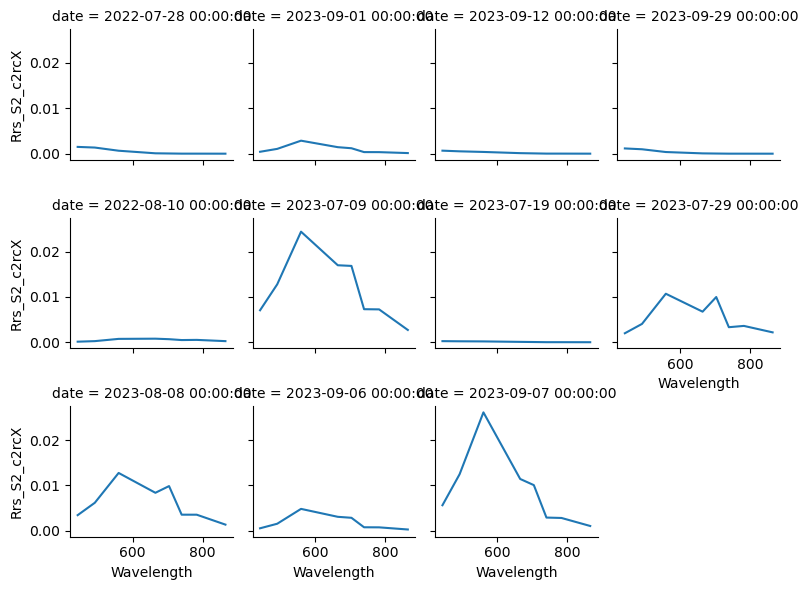

In [323]:
sns.relplot(data=dalec_S2_c2rcX,
            x='Wavelength', y='Rrs_S2_c2rcX', col='date',
            col_wrap=4, kind='line', height=2)

<Axes: xlabel='Wavelength', ylabel='Rrs_S2_c2rcc'>

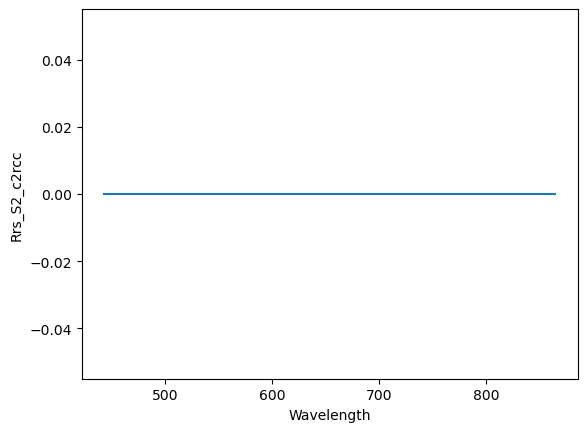

In [324]:
sns.lineplot(data=dalec_S2_c2rcc[dalec_S2_c2rcc.date=='2023-09-12'],
             x='Wavelength', y='Rrs_S2_c2rcc')

In [325]:
dalec_S2_c2rcc[dalec_S2_c2rcc.date=='2023-09-29']

,Wavelength,date,Rrs_DALEC,Date,Rrs_S2_c2rcc,original_date,date_flag
3,443.0,2023-09-29,0.000183,2023-09-29 11:33:19.023999,0.002917,nan,0.0
7,492.0,2023-09-29,0.001823,2023-09-29 11:33:19.023999,0.002343,nan,0.0
11,560.0,2023-09-29,0.003457,2023-09-29 11:33:19.023999,0.000684,nan,0.0
15,665.0,2023-09-29,0.002610,2023-09-29 11:33:19.023999,0.000072,nan,0.0
19,704.0,2023-09-29,0.002497,2023-09-29 11:33:19.023999,0.000040,nan,0.0
23,740.0,2023-09-29,0.001364,2023-09-29 11:33:19.023999,0.000010,nan,0.0
27,783.0,2023-09-29,0.001134,2023-09-29 11:33:19.023999,0.000009,nan,0.0
31,865.0,2023-09-29,0.001384,2023-09-29 11:33:19.023999,0.000003,nan,0.0


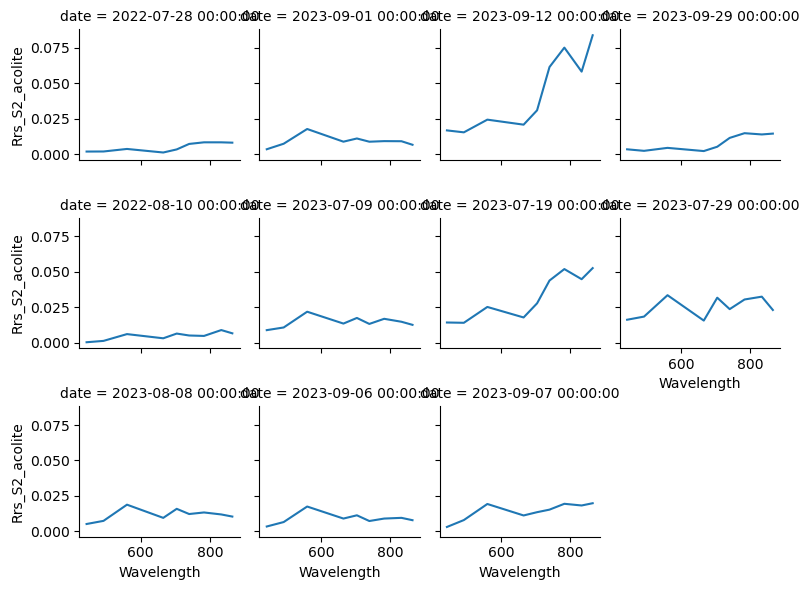

In [326]:
sns.relplot(data=dalec_S2_acolite,
            x='Wavelength', y='Rrs_S2_acolite', col='date',
            col_wrap=4, kind='line', height=2)


wavelength = [443.]
MAE: 0.001718146106995495
MAPE: 412.61230408819466
RMSD: 4.274461336763189
bias: 59.194085594958025
MAD: 3.2691977704570894
MAPD: 81.8728781597363
MDSA: 322.6452397075104
R2: 0.39789516992913765
p-val: 0.09355495449735383

wavelength = [492.]
MAE: 0.002443933780212927
MAPE: 47.23001842084765
RMSD: 1.5626898983190598
bias: -60.52030693087009
MAD: 1.1356764906890904
MAPD: 37.68512666251108
MDSA: 60.52030693087009
R2: 0.0031683557519527473
p-val: 0.8946824342661971

wavelength = [560.]
MAE: 0.006214979890886734
MAPE: 58.640513220236954
RMSD: 2.8125749072974733
bias: -151.96107095713978
MAD: 2.0439987275125744
MAPD: 56.82072772523939
MDSA: 151.96107095713978
R2: 0.5413313750680518
p-val: 0.03747003096066728

wavelength = [665.]
MAE: 0.004372922750532148
MAPE: 65.3825485901941
RMSD: 7.827304059678871
bias: -237.67323555128073
MAD: 4.452564033248409
MAPD: 63.45851111633974
MDSA: 237.67323555128073
R2: 0.4822923959431014
p-val: 0.05596031983465982

wavelength = [704.]
MAE

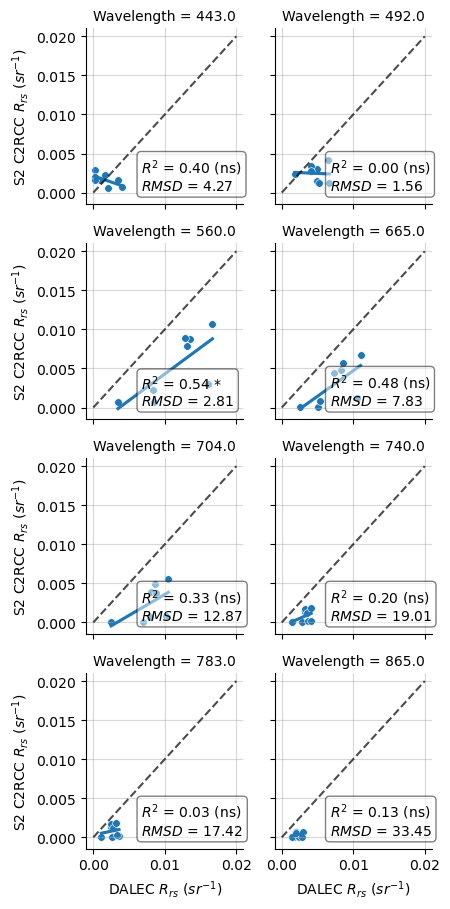

In [327]:
# g = sns.FacetGrid(dalec_sd,#[dalec_sd.year == 2023],
#                   col='Wavelength', col_wrap=2, height=2,
#                   #sharex=False, sharey=False
#                  )

def annotate(data, x='Chl-a', y='sdfkjdf', order=1, plot=True, lims=None, **kws):
    res = sp.stats.linregress(data.dropna()[x]**order, data.dropna()[y])
    mae = MAE(data.dropna()[x], data.dropna()[y])
    mape = MAPE(data.dropna()[x], data.dropna()[y])
    rmsd = RMSD(data.dropna()[x], data.dropna()[y])
    bias = SSPB(data.dropna()[x], data.dropna()[y])
    mad = MAD(data.dropna()[x], data.dropna()[y])
    mapd = MAPD(data.dropna()[x], data.dropna()[y])
    mdsa = MDSA(data.dropna()[x], data.dropna()[y])
    print('\nwavelength = ' + str(data.Wavelength.unique()))
    print('MAE: '+ str(mae))
    print('MAPE: ' + str(mape))
    print('RMSD: ' + str(rmsd))
    print('bias: ' + str(bias))
    print('MAD: ' + str(mad))
    print('MAPD: ' + str(mapd))
    print('MDSA: ' + str(mdsa))
    print('R2: ' + str(res.rvalue**2))
    print('p-val: ' + str(res.pvalue))
    psig = p_sig(res.pvalue)
    
    ax = plt.gca()
    textstr = '\n'.join((
                         r'$R^2$ = {:.2f} {}'.format(res.rvalue**2,
                                                     psig),
                         r'$RMSD$ = {:.2f}'.format(rmsd, )))
    ax.text(0.35, 0.08, textstr,
        transform=ax.transAxes, bbox=dict(boxstyle='round',
                                          facecolor='white',
                                          alpha=0.5),
            )
    
    if plot:
        ax.plot([0.1, 100], [0.1, 100], 'k--', alpha=0.6)
        
g = sns.lmplot(data=dalec_S2_c2rcc[dalec_S2_c2rcc.Rrs_S2_c2rcc!=0], col='Wavelength', col_wrap=2, height=2.3,
                x='Rrs_DALEC', y='Rrs_S2_c2rcc', ci=None, scatter=False)

g.map_dataframe(sns.scatterplot, x='Rrs_DALEC', y='Rrs_S2_c2rcc',
                #style='Sat_ID',
                #hue='year',
                legend=True,
                #style='date',
                s=30)

g.map_dataframe(annotate, x='Rrs_DALEC', y='Rrs_S2_c2rcc', plot=False)# lims=[0.1, 100])


for ax in g.axes.flat[:]:
    ax.plot([0, 0.02], [0, 0.02], 'k--', alpha=0.7)
#     ax.set_xlim(0, 0.02)
#     ax.set_ylim(.3e-3, 0.02)
    ax.grid(alpha=0.5)
    ax.set_xlabel('DALEC $R_{rs}$ ($sr^{-1}$)')
    ax.set_ylabel('S2 C2RCC $R_{rs}$ ($sr^{-1}$)')


# g.set(xscale="log")
# g.set(yscale="log")


plt.tight_layout()
#plt.gca().legend()
# plt.savefig('figures_for_paper/SD_DALEC_match.svg', dpi=300)


plt.show()





wavelength = [443.]
MAE: 0.0021727852487689377
MAPE: 585.9178247287043
RMSD: 6.284044230072037
bias: 26.733103445576823
MAD: 4.057839515952538
MAPD: 96.8581096242876
MDSA: 184.08830306498584
R2: 0.0407293198596631
p-val: 0.5517870803238032

wavelength = [492.]
MAE: 0.003993776265907804
MAPE: 84.2603390284466
RMSD: 4.374184679706552
bias: -261.58789801488706
MAD: 3.0696194629450195
MAPD: 78.57592226022344
MDSA: 261.58789801488706
R2: 0.050602369075416986
p-val: 0.506036622394513

wavelength = [560.]
MAE: 0.008574027438000427
MAPE: 74.08883798403889
RMSD: 7.664992476879835
bias: -370.1653939382326
MAD: 4.73739387628061
MAPD: 89.3098480057551
MDSA: 370.1653939382326
R2: 0.21695587702738475
p-val: 0.14876637936636108

wavelength = [665.]
MAE: 0.00525222529217318
MAPE: 72.50163370376028
RMSD: 12.73387681314415
bias: -473.9819116573318
MAD: 6.815989049004897
MAPD: 85.1622344030917
MDSA: 473.9819116573318
R2: 0.20176657795673109
p-val: 0.16575754749859883

wavelength = [704.]
MAE: 0.00590724

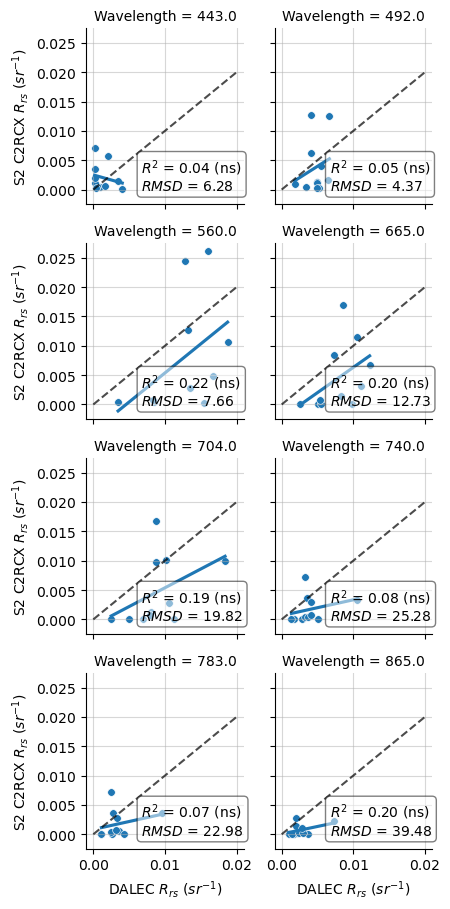

In [328]:
# g = sns.FacetGrid(dalec_sd,#[dalec_sd.year == 2023],
#                   col='Wavelength', col_wrap=2, height=2,
#                   #sharex=False, sharey=False
#                  )

def annotate(data, x='Chl-a', y='sdfkjdf', order=1, plot=True, lims=None, **kws):
    res = sp.stats.linregress(data.dropna()[x]**order, data.dropna()[y])
    mae = MAE(data.dropna()[x], data.dropna()[y])
    mape = MAPE(data.dropna()[x], data.dropna()[y])
    rmsd = RMSD(data.dropna()[x], data.dropna()[y])
    bias = SSPB(data.dropna()[x], data.dropna()[y])
    mad = MAD(data.dropna()[x], data.dropna()[y])
    mapd = MAPD(data.dropna()[x], data.dropna()[y])
    mdsa = MDSA(data.dropna()[x], data.dropna()[y])
    print('\nwavelength = ' + str(data.Wavelength.unique()))
    print('MAE: '+ str(mae))
    print('MAPE: ' + str(mape))
    print('RMSD: ' + str(rmsd))
    print('bias: ' + str(bias))
    print('MAD: ' + str(mad))
    print('MAPD: ' + str(mapd))
    print('MDSA: ' + str(mdsa))
    print('R2: ' + str(res.rvalue**2))
    print('p-val: ' + str(res.pvalue))
    psig = p_sig(res.pvalue)
    
    ax = plt.gca()
    textstr = '\n'.join((
                         r'$R^2$ = {:.2f} {}'.format(res.rvalue**2,
                                                     psig),
                         r'$RMSD$ = {:.2f}'.format(rmsd, )))
    ax.text(0.35, 0.08, textstr,
        transform=ax.transAxes, bbox=dict(boxstyle='round',
                                          facecolor='white',
                                          alpha=0.5),
            )
    
    if plot:
        ax.plot([0.1, 100], [0.1, 100], 'k--', alpha=0.6)
        
g = sns.lmplot(data=dalec_S2_c2rcX[dalec_S2_c2rcX.Rrs_S2_c2rcX!=0], col='Wavelength', col_wrap=2, height=2.3,
                x='Rrs_DALEC', y='Rrs_S2_c2rcX', ci=None, scatter=False)

g.map_dataframe(sns.scatterplot, x='Rrs_DALEC', y='Rrs_S2_c2rcX',
                #style='Sat_ID',
                #hue='year',
                legend=True,
                #style='date',
                s=30)

g.map_dataframe(annotate, x='Rrs_DALEC', y='Rrs_S2_c2rcX', plot=False)# lims=[0.1, 100])


for ax in g.axes.flat[:]:
    ax.plot([0, 0.02], [0, 0.02], 'k--', alpha=0.7)
#     ax.set_xlim(0, 0.02)
#     ax.set_ylim(.3e-3, 0.02)
    ax.grid(alpha=0.5)
    ax.set_xlabel('DALEC $R_{rs}$ ($sr^{-1}$)')
    ax.set_ylabel('S2 C2RCX $R_{rs}$ ($sr^{-1}$)')


# g.set(xscale="log")
# g.set(yscale="log")


plt.tight_layout()
#plt.gca().legend()
# plt.savefig('figures_for_paper/SD_DALEC_match.svg', dpi=300)


plt.show()




/Users/daa5@stir.ac.uk/anaconda3/envs/dalec2/lib/python3.10/site-packages/seaborn/regression.py:582: UserWarning: sharex is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)
/Users/daa5@stir.ac.uk/anaconda3/envs/dalec2/lib/python3.10/site-packages/seaborn/regression.py:582: UserWarning: sharey is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)



wavelength = [443.]
MAE: 0.006727970399370307
MAPE: 2085.124882405979
RMSD: 15.28390403160316
bias: 1795.7262207578785
MAD: 10.518734944240094
MAPD: 1795.7262207578785
MDSA: 1795.7262207578785
R2: 0.3883880569870069
p-val: 0.04051411743760515

wavelength = [492.]
MAE: 0.005041260457433697
MAPE: 114.19390406652361
RMSD: 1.4839118157341504
bias: 49.49631528156413
MAD: 1.1624680541240222
MAPD: 74.24162911610856
MDSA: 151.83265696718266
R2: 0.009730681413918701
p-val: 0.7729238975882327

wavelength = [560.]
MAE: 0.006531103329341839
MAPE: 55.90676339571994
RMSD: 0.6951013462594544
bias: 31.98642945038106
MAD: 0.5660576942820059
MAPD: 43.10512462155419
MDSA: 43.10512462155418
R2: 0.5719203995834894
p-val: 0.007075685268308246

wavelength = [665.]
MAE: 0.0039700378976412235
MAPE: 58.36840901758691
RMSD: 0.9455450430331318
bias: 7.279682054397418
MAD: 0.6231913036682679
MAPD: 29.990613478701317
MDSA: 29.990613478701313
R2: 0.2684211187520491
p-val: 0.10256020422933598

wavelength = [704.]
MA

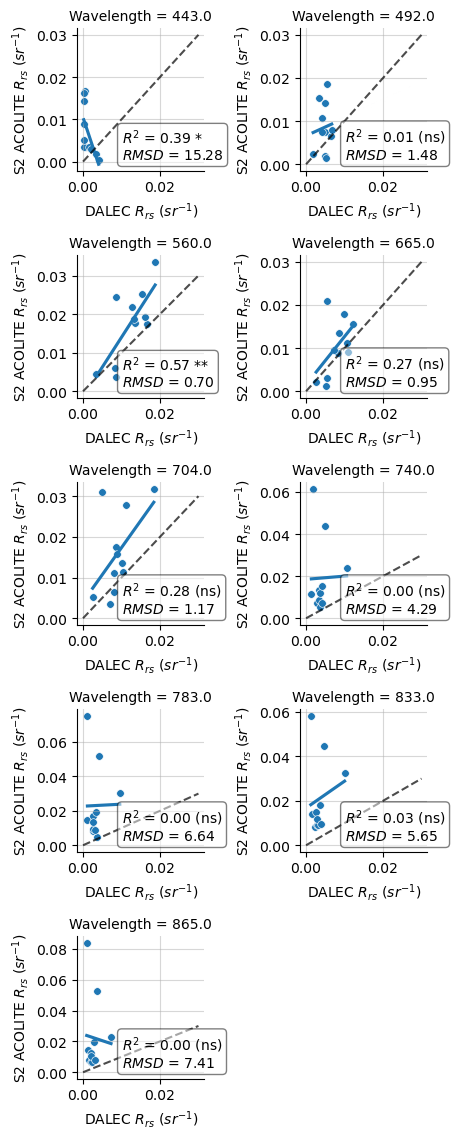

In [329]:
# g = sns.FacetGrid(dalec_sd,#[dalec_sd.year == 2023],
#                   col='Wavelength', col_wrap=2, height=2,
#                   #sharex=False, sharey=False
#                  )

def annotate(data, x='Chl-a', y='sdfkjdf', order=1, plot=True, lims=None, **kws):
    res = sp.stats.linregress(data.dropna()[x]**order, data.dropna()[y])
    mae = MAE(data.dropna()[x], data.dropna()[y])
    mape = MAPE(data.dropna()[x], data.dropna()[y])
    rmsd = RMSD(data.dropna()[x], data.dropna()[y])
    bias = SSPB(data.dropna()[x], data.dropna()[y])
    mad = MAD(data.dropna()[x], data.dropna()[y])
    mapd = MAPD(data.dropna()[x], data.dropna()[y])
    mdsa = MDSA(data.dropna()[x], data.dropna()[y])
    print('\nwavelength = ' + str(data.Wavelength.unique()))
    print('MAE: '+ str(mae))
    print('MAPE: ' + str(mape))
    print('RMSD: ' + str(rmsd))
    print('bias: ' + str(bias))
    print('MAD: ' + str(mad))
    print('MAPD: ' + str(mapd))
    print('MDSA: ' + str(mdsa))
    print('R2: ' + str(res.rvalue**2))
    print('p-val: ' + str(res.pvalue))
    psig = p_sig(res.pvalue)
    
    ax = plt.gca()
    textstr = '\n'.join((
                         r'$R^2$ = {:.2f} {}'.format(res.rvalue**2,
                                                     psig),
                         r'$RMSD$ = {:.2f}'.format(rmsd, )))
    ax.text(0.35, 0.08, textstr,
        transform=ax.transAxes, bbox=dict(boxstyle='round',
                                          facecolor='white',
                                          alpha=0.5),
            )
    
    if plot:
        ax.plot([0.1, 100], [0.1, 100], 'k--', alpha=0.6)
        
g = sns.lmplot(data=dalec_S2_acolite, col='Wavelength', col_wrap=2, height=2.3,
                x='Rrs_DALEC', y='Rrs_S2_acolite', ci=None, scatter=False, sharey=False, sharex=False)

g.map_dataframe(sns.scatterplot, x='Rrs_DALEC', y='Rrs_S2_acolite',
                #style='Sat_ID',
                #hue='year',
                legend=True,
                #style='date',
                s=30)

g.map_dataframe(annotate, x='Rrs_DALEC', y='Rrs_S2_acolite', plot=False)# lims=[0.1, 100])


for ax in g.axes.flat[:]:
    ax.plot([0, 0.03], [0, 0.03], 'k--', alpha=0.7)
#     ax.set_xlim(.3e-3, 0.06)
#     ax.set_ylim(.3e-3, 0.06)
    ax.grid(alpha=0.5)
    ax.set_xlabel('DALEC $R_{rs}$ ($sr^{-1}$)')
    ax.set_ylabel('S2 ACOLITE $R_{rs}$ ($sr^{-1}$)')


# g.set(xscale="log")
# g.set(yscale="log")


plt.tight_layout()
#plt.gca().legend()
# plt.savefig('figures_for_paper/SD_DALEC_match.svg', dpi=300)


plt.show()




/Users/daa5@stir.ac.uk/anaconda3/envs/dalec2/lib/python3.10/site-packages/seaborn/regression.py:582: UserWarning: sharex is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)
/Users/daa5@stir.ac.uk/anaconda3/envs/dalec2/lib/python3.10/site-packages/seaborn/regression.py:582: UserWarning: sharey is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)



wavelength = [443.]
MAE: 0.016574725801761704
MAPE: 5006.81850963311
RMSD: 17.152726314884177
bias: 849.989993203149
MAD: 10.46283642205238
MAPD: 978.8449205523337
MDSA: 849.989993203149
R2: 0.058608798602532174
p-val: 0.5003842372567258

wavelength = [492.]
MAE: 0.010125850445935171
MAPE: 230.94796852254413
RMSD: 1.9970461221187668
bias: 59.93325339215261
MAD: 1.1234654733410827
MAPD: 60.169566211590286
MDSA: 59.93325339215261
R2: 0.0016310391824045055
p-val: 0.911799301756618

wavelength = [560.]
MAE: 0.0047933656744971135
MAPE: 45.23765920913173
RMSD: 0.5938928503231944
bias: 8.79390458279461
MAD: 0.3697579499228718
MAPD: 15.361599877131237
MDSA: 15.91195515360706
R2: 0.32146137193229246
p-val: 0.08742285055353544

wavelength = [665.]
MAE: 0.005600204103370611
MAPE: 72.2730333320809
RMSD: 9.920832283125698
bias: -227.76427925486806
MAD: 5.008146712933574
MAPD: 70.25802586878737
MDSA: 227.76427925486806
R2: 0.3067128394734532
p-val: 0.0967143041277767

wavelength = [704.]
MAE: 0.005

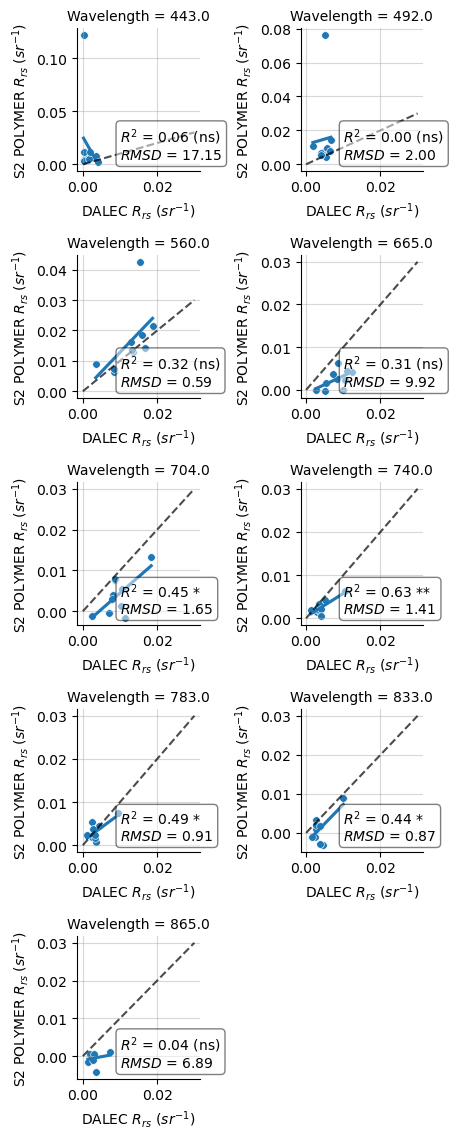

In [330]:
# g = sns.FacetGrid(dalec_sd,#[dalec_sd.year == 2023],
#                   col='Wavelength', col_wrap=2, height=2,
#                   #sharex=False, sharey=False
#                  )

def annotate(data, x='Chl-a', y='sdfkjdf', order=1, plot=True, lims=None, **kws):
    res = sp.stats.linregress(data.dropna()[x]**order, data.dropna()[y])
    mae = MAE(data.dropna()[x], data.dropna()[y])
    mape = MAPE(data.dropna()[x], data.dropna()[y])
    rmsd = RMSD(data.dropna()[x], data.dropna()[y])
    bias = SSPB(data.dropna()[x], data.dropna()[y])
    mad = MAD(data.dropna()[x], data.dropna()[y])
    mapd = MAPD(data.dropna()[x], data.dropna()[y])
    mdsa = MDSA(data.dropna()[x], data.dropna()[y])
    print('\nwavelength = ' + str(data.Wavelength.unique()))
    print('MAE: '+ str(mae))
    print('MAPE: ' + str(mape))
    print('RMSD: ' + str(rmsd))
    print('bias: ' + str(bias))
    print('MAD: ' + str(mad))
    print('MAPD: ' + str(mapd))
    print('MDSA: ' + str(mdsa))
    print('R2: ' + str(res.rvalue**2))
    print('p-val: ' + str(res.pvalue))
    psig = p_sig(res.pvalue)
    
    ax = plt.gca()
    textstr = '\n'.join((
                         r'$R^2$ = {:.2f} {}'.format(res.rvalue**2,
                                                     psig),
                         r'$RMSD$ = {:.2f}'.format(rmsd, )))
    ax.text(0.35, 0.08, textstr,
        transform=ax.transAxes, bbox=dict(boxstyle='round',
                                          facecolor='white',
                                          alpha=0.5),
            )
    
    if plot:
        ax.plot([0.1, 100], [0.1, 100], 'k--', alpha=0.6)
        
g = sns.lmplot(data=dalec_S2_polymer, col='Wavelength', col_wrap=2, height=2.3,
                x='Rrs_DALEC', y='Rrs_S2_polymer', ci=None, scatter=False,
               sharey=False, sharex=False)

g.map_dataframe(sns.scatterplot, x='Rrs_DALEC', y='Rrs_S2_polymer',
                #style='Sat_ID',
                #hue='year',
                legend=True,
                #style='date',
                s=30)

g.map_dataframe(annotate, x='Rrs_DALEC', y='Rrs_S2_polymer', plot=False)# lims=[0.1, 100])


for ax in g.axes.flat[:]:
    ax.plot([0, 0.03], [0, 0.03], 'k--', alpha=0.7)
#     ax.set_xlim(.3e-3, 0.06)
#     ax.set_ylim(.3e-3, 0.06)
    ax.grid(alpha=0.5)
    ax.set_xlabel('DALEC $R_{rs}$ ($sr^{-1}$)')
    ax.set_ylabel('S2 POLYMER $R_{rs}$ ($sr^{-1}$)')


# g.set(xscale="log")
# g.set(yscale="log")


plt.tight_layout()
#plt.gca().legend()
# plt.savefig('figures_for_paper/SD_DALEC_match.svg', dpi=300)


plt.show()




# Where does this leave me?

- acolite currently still looks best
- I should use IDEPIX for mask though?
- need to think about what to do with masks / flags from atmospheric correction:
    - eg. Polymer produces some -ve Rrs
    - Polymer also has 'masked elements..' - could disable this and just use IDEPIX
    - C2RCX is better than C2RCC... what about C2X-COMPLEX-Nets?
    - C2RCC settings?
    - what does C2RCC Rrs==0 mean?
        - think these are cases where the valid pixel expression has returned false
        - I'm running C2RCX with this disabled to see how this affects results!
    - Polymer settings?
    - generally hard to understand why S2 isn't working well...
        - could be worth trying pixels further from the shore?
- think I should also do some more checks to make sure that my processing chain is working fully
    - ie. check Rrs values in SNAP?


In [331]:
dalec_S2_polymer

,Wavelength,date,Rrs_DALEC,Date,Rrs_S2_polymer,original_date,date_flag
0,443.0,2022-07-28,0.003404,2022-07-29 11:43:59,0.007720,2022-07-29,1.0
1,443.0,2023-09-01,0.000871,2023-09-02 11:43:49,0.004496,2023-09-02,1.0
2,443.0,2023-09-29,0.000183,2023-09-29 11:33:19,0.011377,nan,0.0
3,492.0,2022-07-28,0.004902,2022-07-29 11:43:59,0.007425,2022-07-29,1.0
4,492.0,2023-09-01,0.004961,2023-09-02 11:43:49,0.005652,2023-09-02,1.0
...,...,...,...,...,...,...,...
85,865.0,2023-07-19,0.003648,2023-07-19 11:43:51,-0.004278,nan,0.0
86,865.0,2023-07-29,0.007271,2023-07-29 11:43:51,0.001175,nan,0.0
87,865.0,2023-08-08,0.001983,2023-08-08 11:43:51,0.000487,nan,0.0
88,865.0,2023-09-06,0.002989,2023-09-04 11:33:21,0.000461,2023-09-04,1.0


In [332]:
dalec_S2_c2rcX

,Wavelength,date,Rrs_DALEC,Date,Rrs_S2_c2rcX,original_date,date_flag
0,443.0,2022-07-28,0.003404,2022-07-29 11:43:59.023999,0.001499,2022-07-29,1.0
1,443.0,2023-09-01,0.000871,2023-09-02 11:43:49.023999,0.000425,2023-09-02,1.0
2,443.0,2023-09-12,0.000529,2023-09-12 11:43:49.023999,0.000670,nan,0.0
3,443.0,2023-09-29,0.000183,2023-09-29 11:33:19.023999,0.001160,nan,0.0
4,492.0,2022-07-28,0.004902,2022-07-29 11:43:59.023999,0.001356,2022-07-29,1.0
...,...,...,...,...,...,...,...
83,865.0,2023-07-19,0.003648,2023-07-19 11:43:51.023999,0.000008,nan,0.0
84,865.0,2023-07-29,0.007271,2023-07-29 11:43:51.023999,0.002181,nan,0.0
85,865.0,2023-08-08,0.001983,2023-08-08 11:43:51.023999,0.001366,nan,0.0
86,865.0,2023-09-06,0.002989,2023-09-04 11:33:21.023999,0.000291,2023-09-04,1.0


In [333]:
dalec_S2_acolite

,Wavelength,date,Rrs_DALEC,Date,Rrs_S2_acolite,original_date,date_flag
0,443.0,2022-07-28,0.003404,2022-07-29 11:45:40.942094+00:00,0.001898,2022-07-29,1.0
1,443.0,2023-09-01,0.000871,2023-09-02 11:45:40.778585+00:00,0.003524,2023-09-02,1.0
2,443.0,2023-09-12,0.000529,2023-09-12 11:45:39.402233+00:00,0.016816,nan,0.0
3,443.0,2023-09-29,0.000183,2023-09-29 11:35:41.859230+00:00,0.003478,nan,0.0
4,492.0,2022-07-28,0.004902,2022-07-29 11:45:40.942094+00:00,0.001947,2022-07-29,1.0
...,...,...,...,...,...,...,...
94,865.0,2023-07-19,0.003648,2023-07-19 11:45:40.094481+00:00,0.052667,nan,0.0
95,865.0,2023-07-29,0.007271,2023-07-29 11:45:41.220752+00:00,0.023138,nan,0.0
96,865.0,2023-08-08,0.001983,2023-08-08 11:45:40.340448+00:00,0.010432,nan,0.0
97,865.0,2023-09-06,0.002989,2023-09-04 11:35:44.833521+00:00,0.007871,2023-09-04,1.0


In [335]:
for df in [dalec_S2_acolite, dalec_S2_polymer, dalec_S2_c2rcc, dalec_S2_c2rcX]:
    df.drop('Date', axis=1, inplace=True)

In [336]:
on = ['date', 'Wavelength', 'Rrs_DALEC', 'original_date', 'date_flag']
how='outer'
dalec_S2_combo = dalec_S2_acolite.merge(dalec_S2_c2rcX,
                                        on=on,
                                        how=how).merge(dalec_S2_c2rcc,
                                                       on=on,
                                                       how=how).merge(dalec_S2_polymer,
                                                                      on=on,
                                                                      how=how)
dalec_S2_combo

,Wavelength,date,Rrs_DALEC,Rrs_S2_acolite,original_date,date_flag,Rrs_S2_c2rcX,Rrs_S2_c2rcc,Rrs_S2_polymer
0,443.0,2022-07-28,0.003404,0.001898,2022-07-29,1.0,0.001499,0.001576,0.007720
1,443.0,2023-09-01,0.000871,0.003524,2023-09-02,1.0,0.000425,0.001580,0.004496
2,443.0,2023-09-12,0.000529,0.016816,nan,0.0,0.000670,0.000000,NaN
3,443.0,2023-09-29,0.000183,0.003478,nan,0.0,0.001160,0.002917,0.011377
4,492.0,2022-07-28,0.004902,0.001947,2022-07-29,1.0,0.001356,0.001539,0.007425
...,...,...,...,...,...,...,...,...,...
94,865.0,2023-07-19,0.003648,0.052667,nan,0.0,0.000008,0.000000,-0.004278
95,865.0,2023-07-29,0.007271,0.023138,nan,0.0,0.002181,0.000000,0.001175
96,865.0,2023-08-08,0.001983,0.010432,nan,0.0,0.001366,0.000497,0.000487
97,865.0,2023-09-06,0.002989,0.007871,2023-09-04,1.0,0.000291,0.000731,0.000461


In [337]:
dalec_S2_combo_melt = pd.melt(dalec_S2_combo,
                              id_vars=on, value_vars=['Rrs_S2_acolite', 'Rrs_S2_c2rcX',
                                                      'Rrs_S2_c2rcc', 'Rrs_S2_polymer'],
                              var_name='Algorithm', value_name='Rrs')
dalec_S2_combo_melt

,date,Wavelength,Rrs_DALEC,original_date,date_flag,Algorithm,Rrs
0,2022-07-28,443.0,0.003404,2022-07-29,1.0,Rrs_S2_acolite,0.001898
1,2023-09-01,443.0,0.000871,2023-09-02,1.0,Rrs_S2_acolite,0.003524
2,2023-09-12,443.0,0.000529,nan,0.0,Rrs_S2_acolite,0.016816
3,2023-09-29,443.0,0.000183,nan,0.0,Rrs_S2_acolite,0.003478
4,2022-07-28,492.0,0.004902,2022-07-29,1.0,Rrs_S2_acolite,0.001947
...,...,...,...,...,...,...,...
391,2023-07-19,865.0,0.003648,nan,0.0,Rrs_S2_polymer,-0.004278
392,2023-07-29,865.0,0.007271,nan,0.0,Rrs_S2_polymer,0.001175
393,2023-08-08,865.0,0.001983,nan,0.0,Rrs_S2_polymer,0.000487
394,2023-09-06,865.0,0.002989,2023-09-04,1.0,Rrs_S2_polymer,0.000461


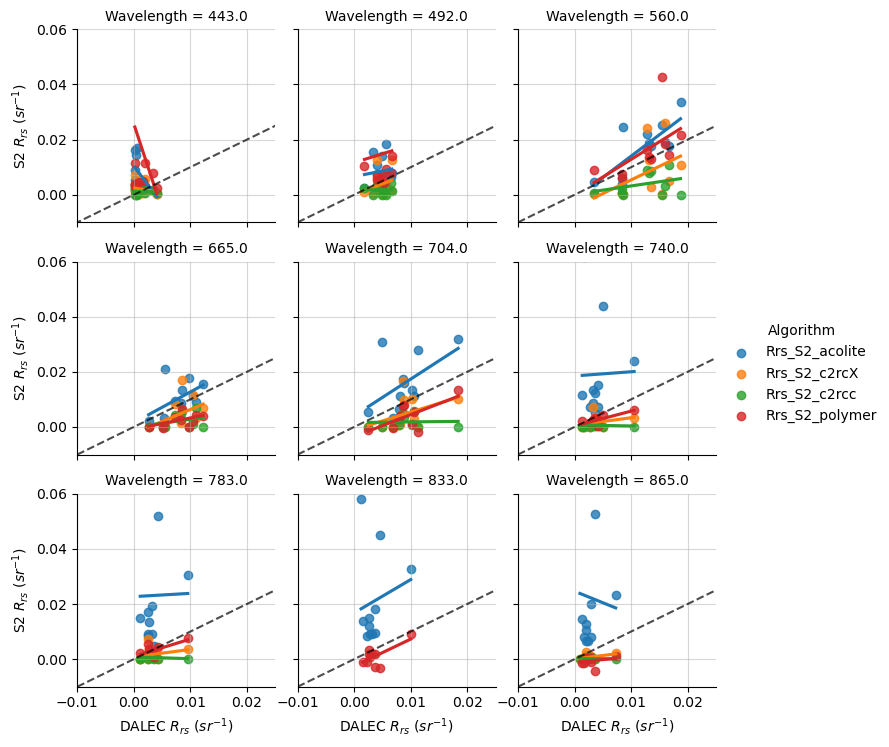

In [338]:
g = sns.lmplot(data=dalec_S2_combo_melt,
               x='Rrs_DALEC', y='Rrs',
               hue='Algorithm',
               col='Wavelength', col_wrap=3,
               facet_kws={'sharey':True, 'sharex':True},
               ci=None,
               height=2.5)

for ax in g.axes.flat[:]:
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    lims = [np.min([xlim, ylim]), np.max([xlim, ylim])]
    ax.plot(lims, lims, 'k--', alpha=0.7)
    ax.set_xlim(-0.01, 0.025)
    ax.set_ylim(-0.01, 0.06)
    ax.grid(alpha=0.5)
    ax.set_xlabel('DALEC $R_{rs}$ ($sr^{-1}$)')
    ax.set_ylabel('S2 $R_{rs}$ ($sr^{-1}$)')
    
# plt.tight_layout()

In [229]:
np.max([[1, 2], [3, 1]], axis=0)

array([3, 2])

In [388]:
def r2_rmse(g):
    try:
        r2 = sp.stats.pearsonr(g.dropna()['Rrs_DALEC'], g.dropna()['Rrs'])[0]**2
        slope = sp.stats.linregress(g.dropna()['Rrs_DALEC'], g.dropna()['Rrs']).slope
        rmse = np.sqrt(mean_squared_error(g.dropna()['Rrs_DALEC'], g.dropna()['Rrs']))
        mape = MAPE(g.dropna()['Rrs_DALEC'], g.dropna()['Rrs'])
        mrd = MRD(g.dropna()['Rrs_DALEC'], g.dropna()['Rrs'])
        return pd.Series(dict(r2 = r2,
                              slope=slope,
                              rmse = rmse,
                              mape=mape,
                              mrd=mrd
                                        ))
    except ValueError:
        return pd.Series(dict(r2 = np.nan,
                              slope=np.nan, 
                              rmse = np.nan,
                              mape=np.nan,
                              mrd=np.nan
                                          ))

In [389]:
metrics = dalec_S2_combo_melt.groupby(['Wavelength', 'Algorithm']).apply(r2_rmse).reset_index()

In [390]:
metrics

,Wavelength,Algorithm,r2,slope,rmse,mape,mrd
0,443.0,Rrs_S2_acolite,0.388388,-2.730146,0.008824,2085.124882,20.606669
1,443.0,Rrs_S2_c2rcX,0.040729,-0.342141,0.002928,585.917825,5.328289
2,443.0,Rrs_S2_c2rcc,0.002088,-0.032857,0.001654,327.354403,2.356514
3,443.0,Rrs_S2_polymer,0.058609,-6.222565,0.038833,5006.818510,49.986628
4,492.0,Rrs_S2_acolite,0.009731,0.406757,0.006637,114.193904,0.897334
5,492.0,Rrs_S2_c2rcX,0.050602,0.773304,0.004514,84.260339,-0.204481
6,492.0,Rrs_S2_c2rcc,0.000040,0.006740,0.003512,61.621832,-0.564445
7,492.0,Rrs_S2_polymer,0.001631,0.643181,0.022961,230.947969,2.268118
8,560.0,Rrs_S2_acolite,0.571920,1.550108,0.008225,55.906763,0.408738
9,560.0,Rrs_S2_c2rcX,0.216956,0.989723,0.009425,74.088838,-0.463738


In [391]:
metrics.to_csv('S2_atmos_corr_metrics_out.csv')

In [379]:
# find best rmse algs
metrics.loc[metrics.groupby('Wavelength').rmse.agg('idxmin')]

,Wavelength,Algorithm,r2,slope,rmse,mape,sspb
2,443.0,Rrs_S2_c2rcc,0.002088,-0.032857,0.001654,327.354403,-115.988910
6,492.0,Rrs_S2_c2rcc,0.000040,0.006740,0.003512,61.621832,-218.503592
8,560.0,Rrs_S2_acolite,0.571920,1.550108,0.008225,55.906763,31.986429
12,665.0,Rrs_S2_acolite,0.268421,1.114934,0.005783,58.368409,7.279682
19,704.0,Rrs_S2_polymer,0.449324,0.796726,0.006410,66.513350,-89.080150
23,740.0,Rrs_S2_polymer,0.627285,0.542279,0.002131,41.704420,-69.419308
27,783.0,Rrs_S2_polymer,0.485152,0.632205,0.001642,49.310940,-30.515783
31,833.0,Rrs_S2_polymer,0.437903,0.982875,0.003624,88.538462,-50.195561
33,865.0,Rrs_S2_c2rcX,0.203712,0.256088,0.002418,79.244369,-926.785241


In [380]:
# find best mape algs 
metrics.loc[metrics.groupby('Wavelength').mape.agg('idxmin')]

,Wavelength,Algorithm,r2,slope,rmse,mape,sspb
2,443.0,Rrs_S2_c2rcc,0.002088,-0.032857,0.001654,327.354403,-115.988910
6,492.0,Rrs_S2_c2rcc,0.000040,0.006740,0.003512,61.621832,-218.503592
11,560.0,Rrs_S2_polymer,0.321461,1.278195,0.008989,45.237659,8.793905
12,665.0,Rrs_S2_acolite,0.268421,1.114934,0.005783,58.368409,7.279682
19,704.0,Rrs_S2_polymer,0.449324,0.796726,0.006410,66.513350,-89.080150
23,740.0,Rrs_S2_polymer,0.627285,0.542279,0.002131,41.704420,-69.419308
27,783.0,Rrs_S2_polymer,0.485152,0.632205,0.001642,49.310940,-30.515783
31,833.0,Rrs_S2_polymer,0.437903,0.982875,0.003624,88.538462,-50.195561
33,865.0,Rrs_S2_c2rcX,0.203712,0.256088,0.002418,79.244369,-926.785241


In [381]:
# find best r2 algs 
metrics.loc[metrics.groupby('Wavelength').r2.agg('idxmax')]

,Wavelength,Algorithm,r2,slope,rmse,mape,sspb
0,443.0,Rrs_S2_acolite,0.388388,-2.730146,0.008824,2085.124882,1795.726221
5,492.0,Rrs_S2_c2rcX,0.050602,0.773304,0.004514,84.260339,-261.587898
8,560.0,Rrs_S2_acolite,0.571920,1.550108,0.008225,55.906763,31.986429
15,665.0,Rrs_S2_polymer,0.306713,0.405323,0.006111,72.273033,-227.764279
19,704.0,Rrs_S2_polymer,0.449324,0.796726,0.006410,66.513350,-89.080150
23,740.0,Rrs_S2_polymer,0.627285,0.542279,0.002131,41.704420,-69.419308
27,783.0,Rrs_S2_polymer,0.485152,0.632205,0.001642,49.310940,-30.515783
31,833.0,Rrs_S2_polymer,0.437903,0.982875,0.003624,88.538462,-50.195561
33,865.0,Rrs_S2_c2rcX,0.203712,0.256088,0.002418,79.244369,-926.785241


# where I'm at now

MASKS (maybe rerun and work out how disable all masking?)
- have applied IDEPix mask
- for c2rcX, the default valid pix thingy is disabled
- for c2rcc valid pix is being used as default
- for polymer I'm using standard settings, which I think includes some masking
- for acolite, I'm using the modified l2w mask (with high threshold for land masking)

Which seems best?
- Polymer seems best at the greens, reds
- c2rcc for blues?

NEXT STEPS:
- decide a sensible masking approach (only idepix? or combine idepix and others?)
    - if I choose only IDEPIX then I'd need to:
        - rerun acolite to get l2R not L2W (that disables masking completely)
        - rerun c2rcc with masking disabled
        - work out how to get non-masked values from Polymer output
- try the other c2rcc (complex X)?
- decide metrics properly (Warren, Spyrakos paper?)
    - warren paper: https://www.sciencedirect.com/science/article/pii/S0034425719301099
    - uses: R2, MAPE, RMSE, mean relative difference
    - I think this seems like a good suite for atmospheric correction checking
    - would make sense to do logspace versions of these for chl-a I think though
- decide approach (i.e. do I just choose best overall, or use different correction for different bands?)
- get Planet SR data for comparison with acolite
